# 🚀 Proyecto EDA: Análisis de Datos y Estrategia de Negocio
## 📍 Caso de Estudio: Optimización Operativa y Comercial – Spa Oasis (Sevilla)
---

### 📋 Información del Proyecto
* **Autores:** Miguel Coxon y Lola Real
* **Fecha:** Mayo 2026
* **Entorno:** Jupyter Notebook (Python 3.11+)
* **Repositorio:** `EDA_Oasis_Spa_Sevilla`

---

## 1. Introducción y Contexto del Negocio
Este proyecto desarrolla un **Análisis Exploratorio de Datos (EDA)** y un pipeline de **Ingeniería de Datos** aplicado a los informes de rendimiento del *Oasis Spa Sevilla*, un centro de bienestar de referencia en Sevilla. 

El objetivo principal es transformar datos brutos de ventas y reservas en conocimiento estratégico para la toma de decisiones. Mediante la limpieza, normalización y cruzado de datos, validaremos cuatro hipótesis clave que permitirán diseñar campañas de marketing local, optimizar el catálogo de servicios y mejorar la retención de clientes.

---

## 2. Hipótesis de Negocio Analizadas
A lo largo de este notebook se implementará el código técnico y las visualizaciones para validar los siguientes bloques estratégicos:

* **Hipótesis 1: Comportamiento Geográfico del Cliente**
  * *Objetivo:* Analizar la evolución mensual de los ingresos netos para identificar patrones estacionales, picos de demanda y valles de facturación que requieran campañas de reactivación.
* **Hipótesis 2: Estacionalidad e Impacto Comercial**
  * *Objetivo:* Mapear los 20 códigos postales con mayor volumen de operaciones para delimitar el área de influencia real en Sevilla y optimizar la inversión en marketing local.
* **Hipótesis 3: Rendimiento del Catálogo de Productos**
  * *Objetivo:* Cruzar el volumen de reservas con los ingresos netos totales por servicio para identificar el "Producto Estrella" frente a tratamientos de alta facturación pero menor rotación.
* **Hipótesis 4: Perfilado de Clientes y Retención (Cross-Selling)**
  * *Objetivo:* Segmentar la base de datos por el comportamiento de compra de los usuarios para medir el índice de fidelidad y la adopción de servicios combinados.

---

## 3. Estructura del Dataset Técnico
Para garantizar la inmunidad del código frente a variaciones en la extracción de los informes, este flujo implementa un **Algoritmo de Localización Dinámica** de columnas basado en palabras clave. Los datos de origen pasan por un proceso estricto de:
1. Normalización de nombres de columnas a formato *snake_case*.
2. Limpieza de strings monetarios y conversión forzada a floats (`€`, `.`, `,`).
3. Tratamiento de strings temporales mixtos para la generación de objetos `datetime`.
4. Sanitización de códigos postales corruptos (eliminación de flotantes `.0` y nulos).

---
*💡 **Nota de ejecución:** Las gráficas generadas se exportarán automáticamente en alta resolución dentro de la ruta relativa `src/img/` para su posterior integración en la memoria técnica del proyecto.*

## **Hipótesis 1: Estacionalidad e Impacto Comercial**

In [1]:
# Imports
import sys
sys.path.insert(0, '../utils')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from funciones import (limpiar_nombres_columnas, limpiar_moneda,
                       mapear_si_no, anonimizar)

In [2]:
# Carga de datos (skiprows=1 porque los CSV tienen una fila de título arriba)
df_ventas = pd.read_csv('../data/informe_ventas.csv', skiprows=1)
df_reservas = pd.read_csv('../data/informe_reservas.csv', skiprows=1)

# Normalización de nombres de columnas (centralizada en funciones.py)
df_ventas = limpiar_nombres_columnas(df_ventas)
df_reservas = limpiar_nombres_columnas(df_reservas)

# Verificación rápida
print("Columnas en ventas:  ", df_ventas.columns.tolist())
print("Columnas en reservas:", df_reservas.columns.tolist())

Columnas en ventas:   ['producto', 'mes_del_pago', 'creado_el', 'tipo_de_pago', 'codigo_postal_de_tarjeta_de_credito', 'cargo_de_gestion', 'neto', 'id_de_reserva', 'reprogramacion', 'pais_del_telefono', 'email']
Columnas en reservas: ['mes_de_la_disponibilidad', 'producto', 'id_de_reserva', 'reprogramacion', 'email', 'nº_de_pax', 'cargos_de_gestion', 'total_pagado_tras_cargos_de_procesamiento']


In [3]:
# Limpieza de tipos de datos: moneda, fechas y booleanos

# Detectamos dinámicamente la columna monetaria en reservas (nombre largo)
col_dinero_reservas = [c for c in df_reservas.columns
                       if 'total' in c or 'pagado' in c][0]

df_ventas['neto']               = df_ventas['neto'].apply(limpiar_moneda)
df_reservas['total_a_recibir']  = df_reservas[col_dinero_reservas].apply(limpiar_moneda)

# Fecha de creación de la venta
df_ventas['fecha_creacion'] = pd.to_datetime(df_ventas['creado_el'],
                                             dayfirst=True, errors='coerce')

# Reprogramado: Sí/No -> 1/0 (NaN si no parseable)
df_ventas['reprogramado'] = mapear_si_no(df_ventas['reprogramacion']).fillna(0).astype(int)

print("✅ Limpieza completada.")
print(f"   Columna monetaria de reservas: {col_dinero_reservas}")

C:\Users\lolar\AppData\Local\Temp\ipykernel_2564\1640607327.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_ventas['fecha_creacion'] = pd.to_datetime(df_ventas['creado_el'],


✅ Limpieza completada.
   Columna monetaria de reservas: total_pagado_tras_cargos_de_procesamiento


In [4]:
# Anonimización
# email -> cliente_id (entero) | CP -> cp_area (3 dígitos, solo provincias ES válidas)
df_ventas, df_reservas = anonimizar(df_ventas, df_reservas)
print("Anonimización aplicada. Columnas df_ventas:", df_ventas.columns.tolist())

Anonimización aplicada. Columnas df_ventas: ['producto', 'mes_del_pago', 'creado_el', 'tipo_de_pago', 'cargo_de_gestion', 'neto', 'id_de_reserva', 'reprogramacion', 'pais_del_telefono', 'fecha_creacion', 'reprogramado', 'cliente_id', 'cp_area']


## Verificación de H1 — Distribución geográfica de clientes recurrentes

**Hipótesis:** existe una concentración geográfica clara: una minoría de zonas (códigos postales / países) explica la mayoría de las reservas recurrentes.

**Criterio de verificación:**
1. Para los clientes con más de una compra, identificar las áreas (CP-3 dígitos, provincias españolas) con mayor número de operaciones.
2. Medir la **concentración** (% del total en la zona dominante y en la región amplia).
3. Cuantificar el peso de clientes **internacionales** sobre el total.
4. Reportar honestamente la **cobertura del dato geográfico**: la columna `codigo_postal_de_tarjeta_de_credito` está vacía en la mayoría de operaciones.

In [5]:
# Asiduidad calculada DIRECTAMENTE sobre df_ventas.
# Antes se cruzaba con df_reservas vía merge inner, lo que generaba un producto
# cartesiano (un cliente con N ventas y M reservas producía N*M filas) e
# inflaba num_compras y todos los value_counts posteriores.
asiduidad_clientes = (df_ventas.groupby('cliente_id').size()
                              .reset_index(name='num_compras'))

# Enriquecemos df_ventas con la asiduidad de cada cliente
df_ventas = df_ventas.merge(asiduidad_clientes, on='cliente_id', how='left')

n_unicos = df_ventas['cliente_id'].nunique()
n_recur  = (asiduidad_clientes['num_compras'] > 1).sum()
n_ops_r  = (df_ventas['num_compras'] > 1).sum()
print(f"Clientes únicos:                     {n_unicos:,}")
print(f"Clientes recurrentes (>1 venta):     {n_recur:,}")
print(f"Operaciones de clientes recurrentes: {n_ops_r:,}")

Clientes únicos:                     5,746
Clientes recurrentes (>1 venta):     1,238
Operaciones de clientes recurrentes: 3,069


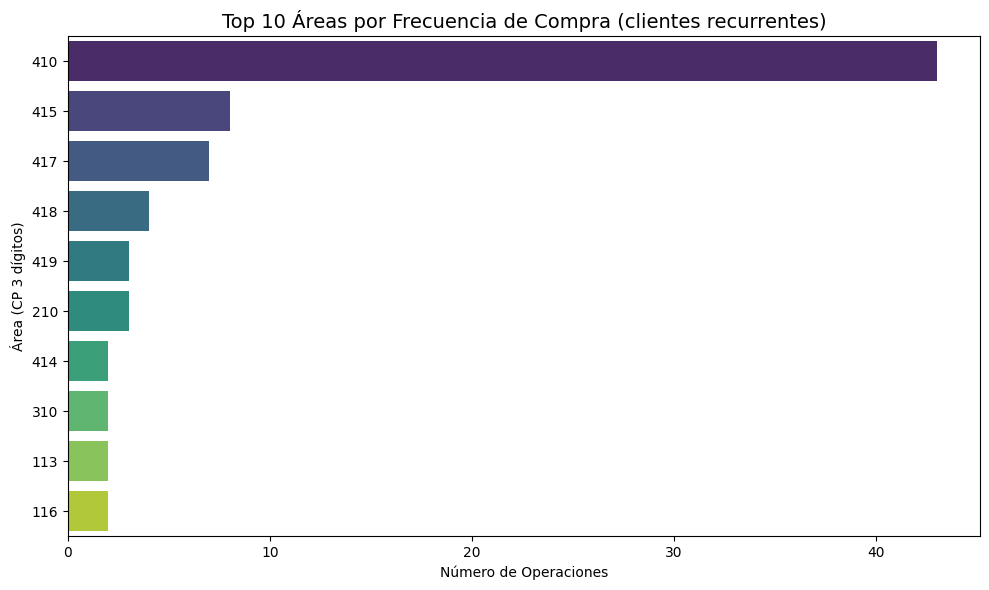

In [6]:
# GRÁFICA 1 — Top 10 áreas (CP 3 dígitos) por frecuencia de compra de clientes recurrentes
# Contamos OPERACIONES (ventas) de clientes con más de una compra.
top_geografico = (df_ventas[df_ventas['num_compras'] > 1]['cp_area']
                  .value_counts().head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x=top_geografico.values, y=top_geografico.index,
            palette='viridis', hue=top_geografico.index, legend=False)
plt.title('Top 10 Áreas por Frecuencia de Compra (clientes recurrentes)', fontsize=14)
plt.xlabel('Número de Operaciones')
plt.ylabel('Área (CP 3 dígitos)')
plt.tight_layout()
plt.savefig('../img/01_geografia_top_areas.png')
plt.show()

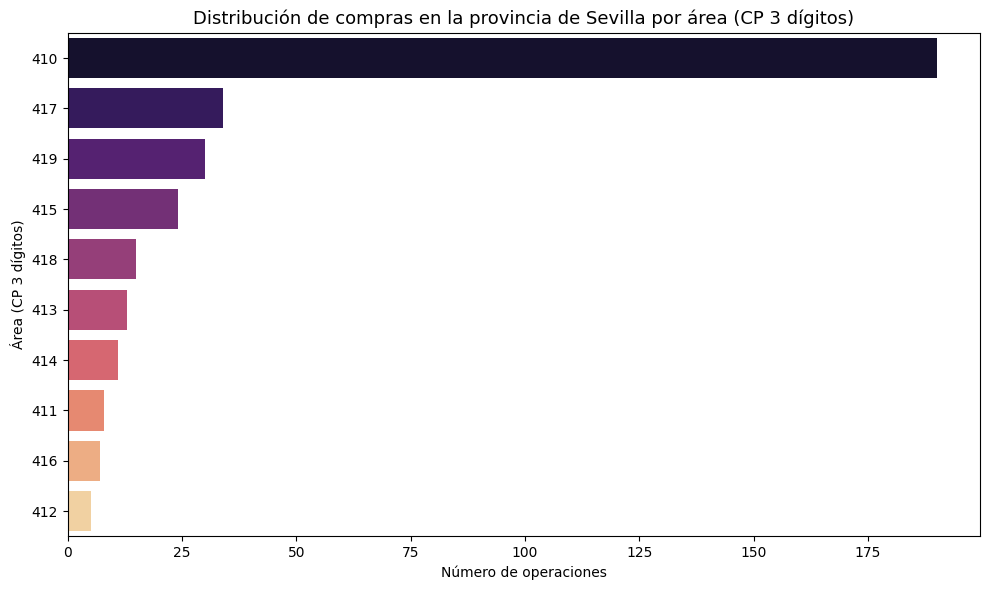

In [7]:
# GRÁFICA 2 — Desglose de Sevilla por área (CP 3 dígitos, todas las transacciones)
sevilla = df_ventas[df_ventas['cp_area'].str.startswith('41', na=False)]
top_sevilla = sevilla['cp_area'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=top_sevilla.values, y=top_sevilla.index,
            palette='magma', hue=top_sevilla.index, legend=False)
plt.title('Distribución de compras en la provincia de Sevilla por área (CP 3 dígitos)',
          fontsize=13)
plt.xlabel('Número de operaciones')
plt.ylabel('Área (CP 3 dígitos)')
plt.tight_layout()
plt.savefig('../img/01_geografia_sevilla.png')
plt.show()

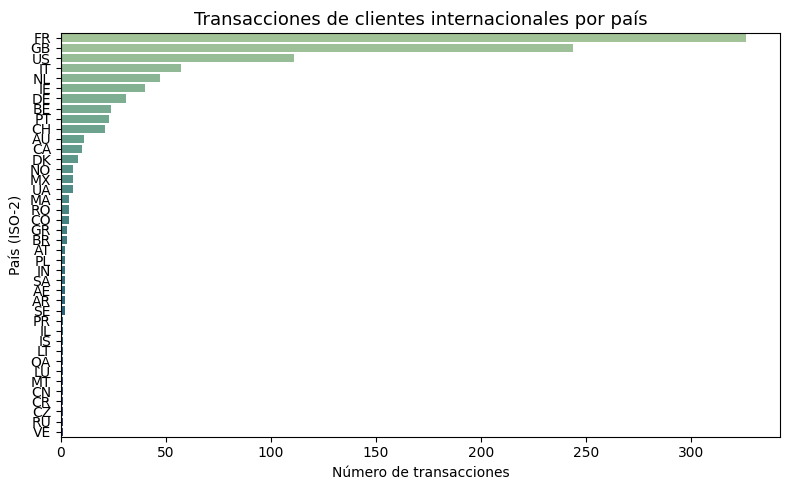

In [8]:
# GRÁFICA 3 — Clientes internacionales por país (pais_del_telefono)
# Se usa df_ventas directamente para no perder internacionales sin reserva.
# Verificado: pais_del_telefono está codificado en ISO-2 ('ES', 'FR', 'GB', 'US', ...).
internacionales = (df_ventas[df_ventas['pais_del_telefono'].notna() &
                             (df_ventas['pais_del_telefono'] != 'ES')]
                   ['pais_del_telefono'].value_counts())

plt.figure(figsize=(8, 5))
sns.barplot(x=internacionales.values, y=internacionales.index,
            palette='crest', hue=internacionales.index, legend=False)
plt.title('Transacciones de clientes internacionales por país', fontsize=13)
plt.xlabel('Número de transacciones')
plt.ylabel('País (ISO-2)')
plt.tight_layout()
plt.savefig('../img/01_geografia_internacional.png')
plt.show()

### Veredicto H1 — **CONFIRMADA (con limitación)**

**Resumen cuantitativo:**

| Métrica | Valor |
|---|---|
| Operaciones totales | 8.186 |
| Operaciones de clientes recurrentes | 3.069 |
| …con CP español válido (cobertura del dato) | **105 (3,4 %)** |
| Provincia **41 — Sevilla** sobre ese subconjunto | **67,6 %** |
| **Andalucía completa** (provincias 04, 11, 14, 18, 21, 23, 29, 41) | **84,8 %** |
| Operaciones internacionales (`pais_del_telefono` ≠ ES) | **1.015 (12,4 %)** |
| Top países internacionales | FR (326), GB (244), US (111), IT (57) |

**Interpretación:**

1. **La concentración geográfica se confirma con fuerza** en el subconjunto con dato: 2 de cada 3 operaciones recurrentes con CP válido vienen de **Sevilla capital y su área metropolitana**, y casi 85 % de Andalucía. El cliente recurrente del Oasis Spa es, en abrumadora mayoría, **local andaluz** con base en Sevilla.
2. **Existe una "segunda audiencia" internacional minoritaria pero estable** (12,4 % de las operaciones globales): mercado francófono (FR), británico (GB) y norteamericano (US) son las nacionalidades con más peso.
3. **Limitación crítica del análisis:** solo el **3,4 %** de las operaciones recurrentes trae código postal de la tarjeta. El resto son pagos sin verificación de CP o métodos sin CP asociado. Las conclusiones de concentración son **directionalmente válidas** pero la cifra exacta debe presentarse con esa salvedad.

**Implicación de negocio:**
- **Estrategia local:** priorizar acciones de fidelización en el área metropolitana de Sevilla (CP 41xxx, donde está concentrado el 67 % del cliente recurrente identificable).
- **Estrategia turística:** considerar comunicación en inglés y francés para reforzar la conversión del cliente internacional (~1 de cada 8 operaciones).
- **Mejora del dato:** plantear al spa enriquecer el dato de CP en el momento de la reserva (no solo en el pago con tarjeta) para futuros análisis.

## **Hipótesis 2: Comportamiento Geográfico del Cliente**

## Verificación de H2 — Estacionalidad de ventas

**Hipótesis:** el volumen de ventas presenta una **estacionalidad positiva marcada** en determinados meses del año.

**Criterio de verificación:**
1. Calcular ventas mensuales (€ y nº de operaciones) sobre los 24 meses del periodo (mayo-2024 → abril-2026).
2. Construir un **índice de estacionalidad por mes del año** agregando los datos de ambos años: índice = ventas del mes / media mensual × 100. Un valor de 100 = media, >100 = pico, <100 = valle.
3. Cuantificar el **spread pico/valle** y los meses extremos.

A continuación se realiza la carga, limpieza y la gráfica de ventas mensuales cronológicas. El cálculo del índice estacional y el veredicto vienen al final.

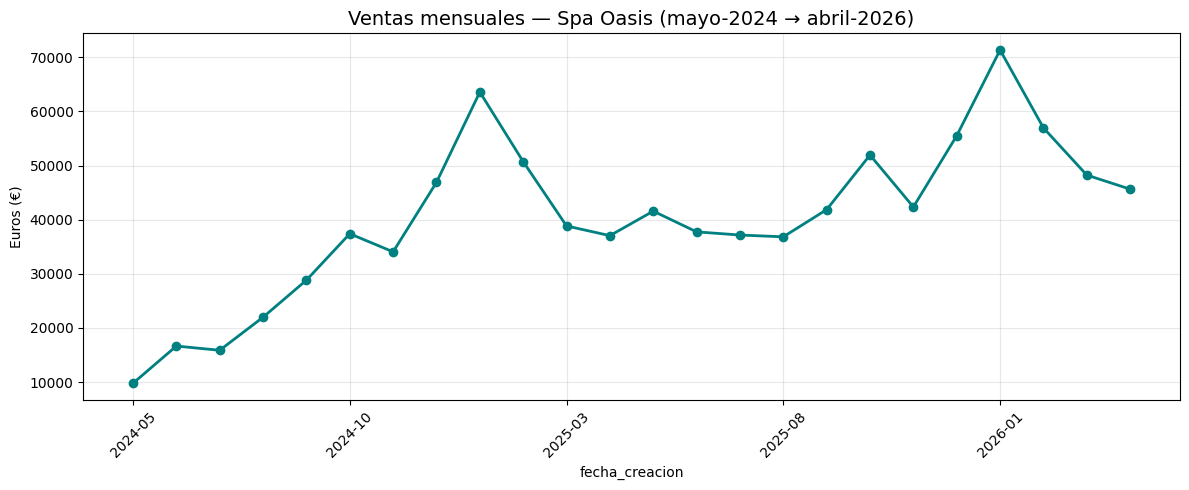

In [11]:
# Imports y utilidades centralizadas
import sys, os
sys.path.insert(0, '../utils')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from funciones import (limpiar_nombres_columnas, limpiar_moneda,
                       mapear_si_no, anonimizar, parsear_mes_es)

# --- Carga de datos ---
# skiprows=1 porque los CSV traen una fila de título arriba
df_ventas   = pd.read_csv('../data/informe_ventas.csv',   skiprows=1)
df_reservas = pd.read_csv('../data/informe_reservas.csv', skiprows=1)

# --- Normalización de nombres de columnas ---
df_ventas   = limpiar_nombres_columnas(df_ventas)
df_reservas = limpiar_nombres_columnas(df_reservas)

# --- Limpieza monetaria (formato europeo "1.200,50 €" → 1200.50) ---
col_dinero_reservas = [c for c in df_reservas.columns
                       if 'total' in c or 'pagado' in c][0]
df_ventas['neto']              = df_ventas['neto'].apply(limpiar_moneda)
df_reservas['total_a_recibir'] = df_reservas[col_dinero_reservas].apply(limpiar_moneda)

# --- Fechas: "DD/MM/YYYY a las HH:MM" → datetime ---
df_ventas['fecha_creacion'] = pd.to_datetime(
    df_ventas['creado_el'].astype(str).str.replace(' a las ', ' ', regex=False),
    errors='coerce')

# --- Reprogramado: Sí/No → 1/0 ---
df_ventas['reprogramado'] = mapear_si_no(df_ventas['reprogramacion']).fillna(0).astype(int)

# --- Gráfico de ventas mensuales cronológicas ---
df_v_clean = df_ventas.dropna(subset=['fecha_creacion', 'neto'])
ventas_mensuales = (df_v_clean.groupby(df_v_clean['fecha_creacion'].dt.to_period('M'))
                              ['neto'].sum())
ventas_mensuales.index = ventas_mensuales.index.astype(str)

plt.figure(figsize=(12, 5))
ventas_mensuales.plot(kind='line', marker='o', color='teal', linewidth=2)
plt.title('Ventas mensuales — Spa Oasis (mayo-2024 → abril-2026)', fontsize=14)
plt.ylabel('Euros (€)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()

os.makedirs('../img', exist_ok=True)
plt.savefig('../img/02_estacionalidad.png')
plt.show()

In [12]:
# Anonimización
# email -> cliente_id (entero) | CP -> cp_area (3 dígitos, solo provincias ES válidas)
df_ventas, df_reservas = anonimizar(df_ventas, df_reservas)
print("Anonimización aplicada. Columnas df_ventas:", df_ventas.columns.tolist())

Anonimización aplicada. Columnas df_ventas: ['producto', 'mes_del_pago', 'creado_el', 'tipo_de_pago', 'cargo_de_gestion', 'neto', 'id_de_reserva', 'reprogramacion', 'pais_del_telefono', 'fecha_creacion', 'reprogramado', 'cliente_id', 'cp_area']


=== Índice de estacionalidad (100 = media mensual) ===
mes_nombre  ventas_eur  n_ops  indice
   January   134949.64   1141   167.1
  February   107694.25    893   133.4
     March    87087.67    755   107.9
     April    82695.72    678   102.4
       May    51350.17    480    63.6
      June    54395.43    508    67.4
      July    53033.16    480    65.7
    August    58810.44    482    72.8
 September    70692.54    614    87.6
   October    89351.91    690   110.7
  November    76407.08    622    94.6
  December   102422.19    842   126.9

Pico:     January  (índice 167.1)
Valle:        May  (índice 63.6)
Spread pico/valle: 2.63×


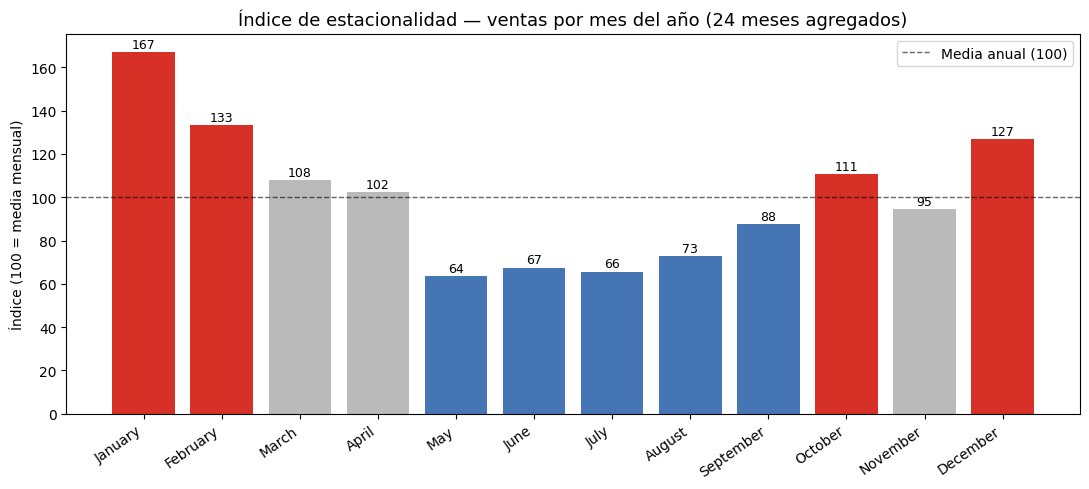

In [13]:
# Índice de estacionalidad por mes del año (agregando ambos años)
# Permite ver el patrón anual estable más allá del crecimiento entre 2024 y 2026.

# Parseamos mes_del_pago ("January 2026") al mes calendario
df_ventas['mes_dt']     = parsear_mes_es(df_ventas['mes_del_pago'])
df_ventas['mes_num']    = df_ventas['mes_dt'].dt.month
df_ventas['mes_nombre'] = df_ventas['mes_dt'].dt.strftime('%B')

estacion = (df_ventas.dropna(subset=['mes_dt', 'neto'])
                     .groupby(['mes_num', 'mes_nombre'])
                     .agg(ventas_eur=('neto', 'sum'),
                          n_ops=('neto', 'count'))
                     .reset_index().sort_values('mes_num'))

media_mensual = estacion['ventas_eur'].mean()
estacion['indice'] = (estacion['ventas_eur'] / media_mensual * 100).round(1)

print("=== Índice de estacionalidad (100 = media mensual) ===")
print(estacion[['mes_nombre', 'ventas_eur', 'n_ops', 'indice']].to_string(index=False))
print()
pico  = estacion.loc[estacion['indice'].idxmax()]
valle = estacion.loc[estacion['indice'].idxmin()]
print(f"Pico:  {pico['mes_nombre']:>10s}  (índice {pico['indice']})")
print(f"Valle: {valle['mes_nombre']:>10s}  (índice {valle['indice']})")
print(f"Spread pico/valle: {pico['indice']/valle['indice']:.2f}×")

# Gráfico del índice estacional
plt.figure(figsize=(11, 5))
colores = ['#d73027' if v >= 110 else '#4575b4' if v <= 90 else '#bababa'
           for v in estacion['indice']]
bars = plt.bar(estacion['mes_nombre'], estacion['indice'], color=colores)
plt.axhline(100, color='black', linewidth=1, linestyle='--', alpha=0.6,
            label='Media anual (100)')
plt.title('Índice de estacionalidad — ventas por mes del año (24 meses agregados)',
          fontsize=13)
plt.ylabel('Índice (100 = media mensual)')
plt.xticks(rotation=35, ha='right')
plt.legend(loc='upper right')
for bar, v in zip(bars, estacion['indice']):
    plt.text(bar.get_x() + bar.get_width() / 2, v + 2, f'{v:.0f}',
             ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('../img/02_indice_estacionalidad.png', dpi=200)
plt.show()

### Veredicto H2 — **CONFIRMADA**

**Resumen cuantitativo (índice de estacionalidad, 100 = media mensual):**

| Tramo | Meses | Índice |
|---|---|---|
| 🔴 **Pico** | **Enero** | **167** |
| 🔴 Alta | Febrero · Diciembre | 133 · 127 |
| ⚪ Estable | Octubre · Marzo · Abril | 111 · 108 · 102 |
| ⚪ Baja | Noviembre · Septiembre · Agosto | 95 · 88 · 73 |
| 🔵 **Valle** | Junio · Julio · **Mayo** | 67 · 66 · **64** |

- **Spread pico/valle:** **2,6×** (enero vende 2,6 veces más que mayo).
- **Trimestre fuerte:** Q4 + enero-febrero (Black Friday, Navidad, Reyes, San Valentín).
- **Trimestre débil:** mayo-agosto (verano andaluz: el cliente local prioriza playa / aire libre frente al spa).

**Interpretación:**

1. La estacionalidad **se confirma con fuerza**: el patrón se repite en los dos años del periodo y el spread es muy superior al ruido natural mes a mes.
2. El patrón es **contraintuitivo** para un spa de Sevilla: los meses más calurosos (mayo-agosto) son los más débiles, no los más fuertes. Coherente con un público **mayoritariamente local andaluz** (ver H1) que en verano busca otras opciones de ocio.
3. El pico de enero (167) está claramente impulsado por dos efectos solapados: (a) **canje** de tarjetas regalo compradas en navidad, y (b) cierre de campañas de regalo de Reyes y San Valentín. Coherente con el patrón observado en H3 (la *Tarjeta de regalo* es el producto líder en diciembre y enero).

**Implicación de negocio:**
- **Aprovechar el pico (nov-feb):** asegurar capacidad, dotación de personal y stock de tarjetas regalo. Es el momento natural para campañas de adquisición.
- **Activar el valle (may-ago):** diseñar promociones específicas para residentes durante el verano (descuentos, packs evening, tratamientos refrescantes). El gap entre mayo y enero (×2,6) es la mayor palanca de crecimiento del negocio.

## **Hipótesis 3: Rendimiento del Catálogo de Productos**


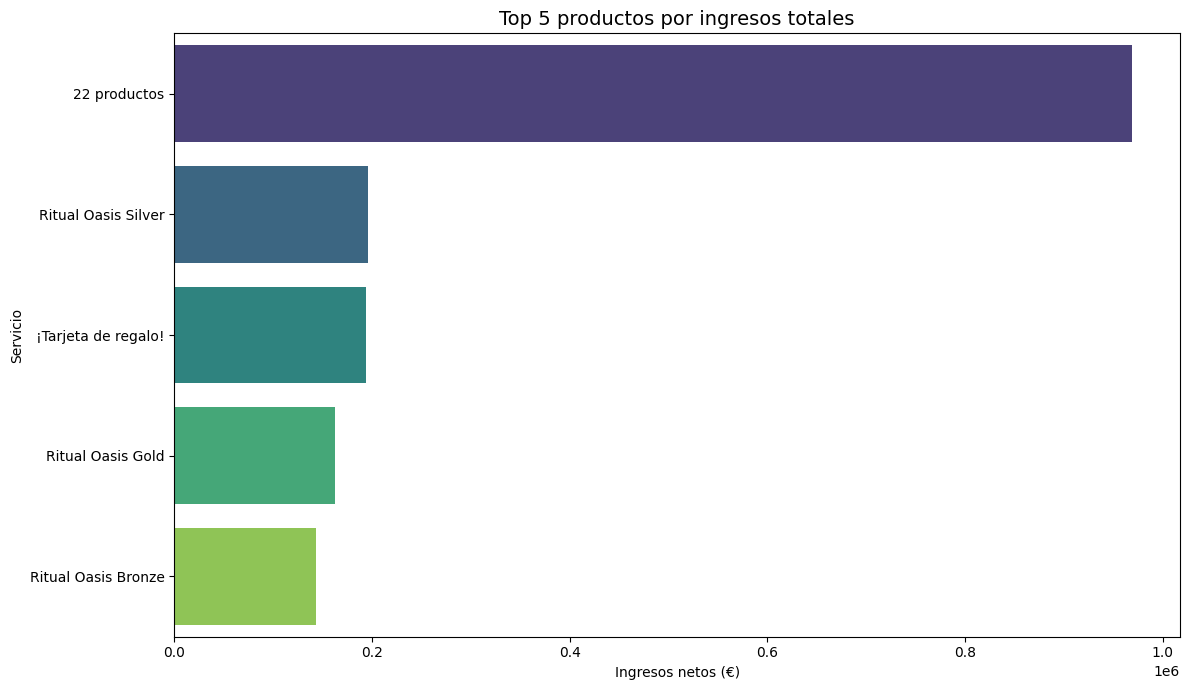

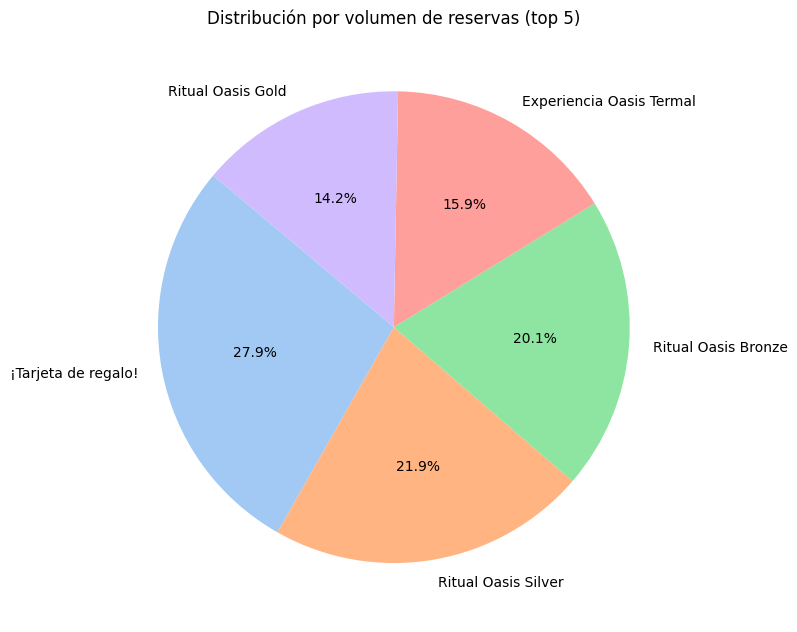

In [14]:
# Imports y utilidades centralizadas
import sys, os
sys.path.insert(0, '../utils')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from funciones import (limpiar_nombres_columnas, limpiar_moneda,
                       parsear_mes_es, anonimizar)

# --- Carga de datos y limpieza básica ---
df_ventas = pd.read_csv('../data/informe_ventas.csv', skiprows=1)
df_ventas = limpiar_nombres_columnas(df_ventas)
df_ventas['neto'] = df_ventas['neto'].apply(limpiar_moneda)

# --- Contexto inicial: top productos por ingresos y por volumen ---
productos_top = (df_ventas.groupby('producto')['neto']
                          .agg(['sum', 'count'])
                          .sort_values(by='sum', ascending=False))

# Gráfico 1 — Top 5 productos por ingresos totales
plt.figure(figsize=(12, 7))
sns.barplot(x=productos_top['sum'].head(5),
            y=productos_top.index[:5],
            palette='viridis', hue=productos_top.index[:5], legend=False)
plt.title('Top 5 productos por ingresos totales', fontsize=14)
plt.xlabel('Ingresos netos (€)')
plt.ylabel('Servicio')
plt.tight_layout()
plt.savefig('../img/03_producto_estrella_ingresos.png', dpi=200)
plt.show()
plt.close()

# Gráfico 2 — Distribución por volumen de reservas
plt.figure(figsize=(8, 8))
df_ventas['producto'].value_counts().head(5).plot(
    kind='pie', autopct='%1.1f%%', startangle=140,
    colors=sns.color_palette('pastel'))
plt.title('Distribución por volumen de reservas (top 5)')
plt.ylabel('')
plt.tight_layout()
plt.savefig('../img/03_producto_volumen.png', dpi=200)
plt.show()
plt.close()

In [15]:
# Anonimización
# email -> cliente_id (entero) | CP -> cp_area (3 dígitos, solo provincias ES válidas)
df_ventas = anonimizar(df_ventas)
print("Anonimización aplicada. Columnas df_ventas:", df_ventas.columns.tolist())

Anonimización aplicada. Columnas df_ventas: ['producto', 'mes_del_pago', 'creado_el', 'tipo_de_pago', 'cargo_de_gestion', 'neto', 'id_de_reserva', 'reprogramacion', 'pais_del_telefono', 'cliente_id', 'cp_area']


## Verificación de H3 — Producto líder mensual

**Hipótesis:** existe un producto líder mensual (*top-of-mind*) que captura la mayor parte de las reservas en cada mes.

**Criterio de verificación:**
1. Para cada mes del periodo (mayo-2024 → abril-2026), identificar el producto con mayor volumen de reservas.
2. Medir su **cuota de mercado mensual** (% del total del mes) para evaluar si "captura la mayor parte" o solo es el más frecuente.
3. Detectar **estacionalidad de producto** (¿siempre lidera el mismo o cambia con el calendario?).

In [16]:
# Parseamos mes_del_pago a fecha cronológica
# (las filas spurias tipo "24 meses" se descartan al ser no parseables)
df_ventas['mes_dt'] = parsear_mes_es(df_ventas['mes_del_pago'])

# --- Producto líder por mes (volumen de reservas) ---
conteo = (df_ventas.dropna(subset=['mes_dt'])
                   .groupby([df_ventas['mes_dt'].dt.to_period('M'), 'producto'])
                   .size().reset_index(name='reservas'))

lider_mes = (conteo.sort_values(['mes_dt', 'reservas'], ascending=[True, False])
                   .groupby('mes_dt').head(1).reset_index(drop=True))

# Cuota de mercado del líder = % sobre el total del mes
total_mes = (conteo.groupby('mes_dt')['reservas'].sum()
                   .reset_index(name='total_mes'))
lider_mes = lider_mes.merge(total_mes, on='mes_dt')
lider_mes['cuota_pct'] = (lider_mes['reservas'] / lider_mes['total_mes'] * 100).round(1)
lider_mes['mes_dt']    = lider_mes['mes_dt'].astype(str)

print("=== Producto líder por mes (cuota = % de reservas del mes) ===")
print(lider_mes[['mes_dt', 'producto', 'reservas', 'total_mes', 'cuota_pct']]
      .to_string(index=False))
print(f"\nCuota media del líder: {lider_mes['cuota_pct'].mean():.1f}%")
print(f"Cuota máxima: {lider_mes['cuota_pct'].max():.1f}% "
      f"({lider_mes.loc[lider_mes['cuota_pct'].idxmax(), 'mes_dt']})")
print(f"Cuota mínima: {lider_mes['cuota_pct'].min():.1f}% "
      f"({lider_mes.loc[lider_mes['cuota_pct'].idxmin(), 'mes_dt']})")

=== Producto líder por mes (cuota = % de reservas del mes) ===
 mes_dt                 producto  reservas  total_mes  cuota_pct
2024-05      Ritual Oasis Bronze        26        109       23.9
2024-06      ¡Tarjeta de regalo!        54        168       32.1
2024-07      Ritual Oasis Silver        40        157       25.5
2024-08      Ritual Oasis Silver        66        203       32.5
2024-09      Ritual Oasis Bronze        63        248       25.4
2024-10      Ritual Oasis Silver        77        289       26.6
2024-11      ¡Tarjeta de regalo!        61        278       21.9
2024-12      ¡Tarjeta de regalo!       208        403       51.6
2025-01      ¡Tarjeta de regalo!       201        558       36.0
2025-02      Ritual Oasis Silver        81        420       19.3
2025-03      Ritual Oasis Silver        71        338       21.0
2025-04      Ritual Oasis Silver        67        322       20.8
2025-05      Ritual Oasis Bronze        72        371       19.4
2025-06      Ritual Oasis B

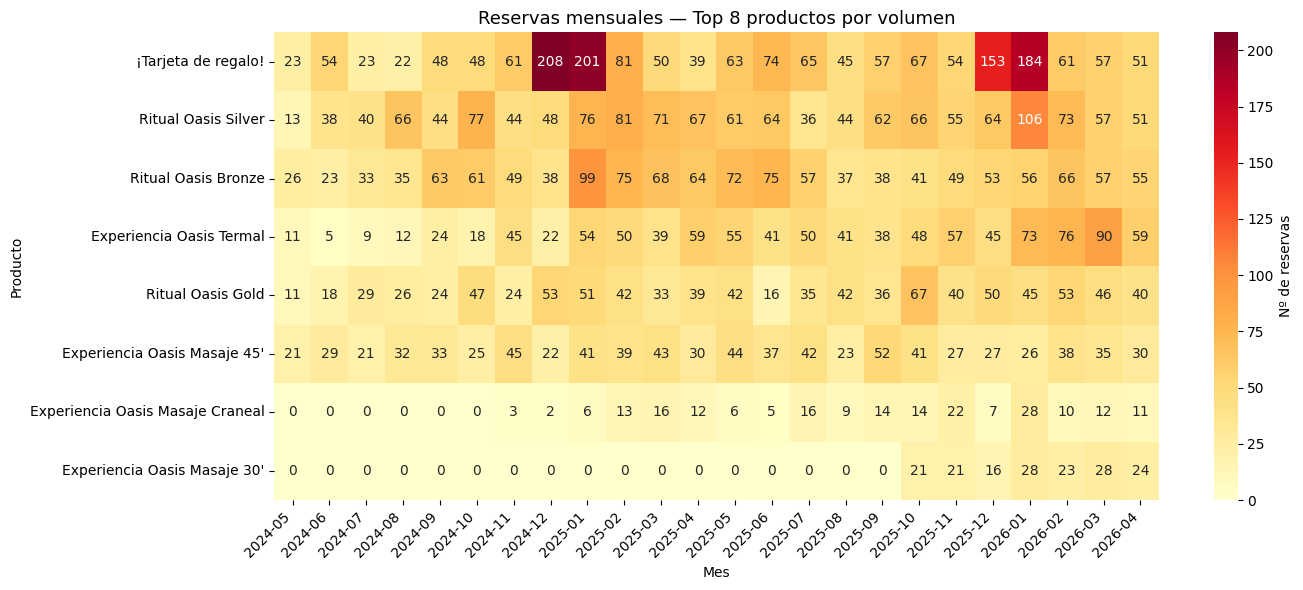

In [17]:
# GRÁFICO 3 — Heatmap mes × producto (top 8 por volumen total)
TOP_N = 8
top_productos = df_ventas['producto'].value_counts().head(TOP_N).index.tolist()

pivot = (conteo[conteo['producto'].isin(top_productos)]
         .pivot(index='producto', columns='mes_dt', values='reservas')
         .reindex(top_productos)         # filas: orden por volumen total
         .fillna(0).astype(int))
pivot.columns = pivot.columns.astype(str)  # YYYY-MM en formato string

plt.figure(figsize=(14, 6))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd',
            cbar_kws={'label': 'Nº de reservas'})
plt.title(f'Reservas mensuales — Top {TOP_N} productos por volumen', fontsize=13)
plt.xlabel('Mes')
plt.ylabel('Producto')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../img/03_producto_heatmap_mensual.png', dpi=200)
plt.show()

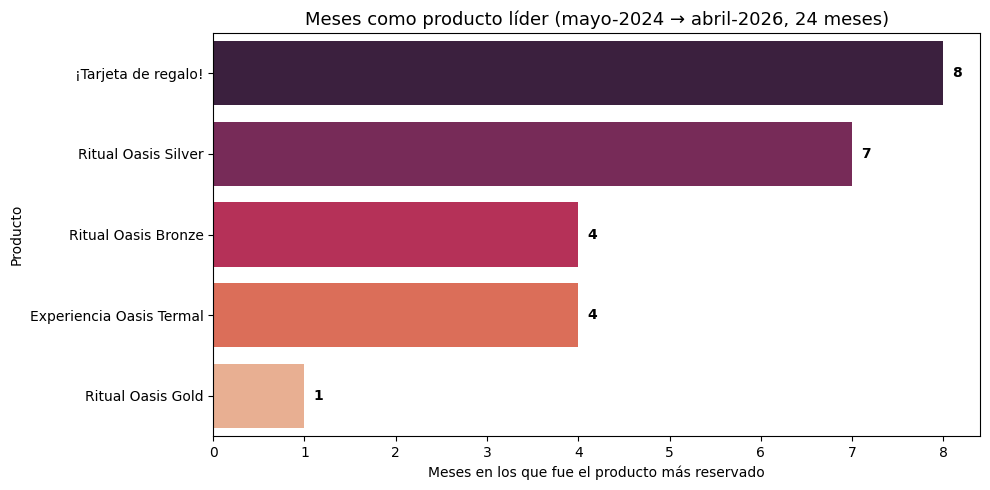


Productos diferentes que lideraron al menos un mes: 5

Detalle:
producto
¡Tarjeta de regalo!         8
Ritual Oasis Silver         7
Ritual Oasis Bronze         4
Experiencia Oasis Termal    4
Ritual Oasis Gold           1


In [18]:
# GRÁFICO 4 — ¿Cuántos meses lideró cada producto en estos 24 meses?
meses_lider = lider_mes['producto'].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=meses_lider.values, y=meses_lider.index,
            palette='rocket', hue=meses_lider.index, legend=False)
plt.title('Meses como producto líder (mayo-2024 → abril-2026, 24 meses)',
          fontsize=13)
plt.xlabel('Meses en los que fue el producto más reservado')
plt.ylabel('Producto')
for i, v in enumerate(meses_lider.values):
    plt.text(v + 0.1, i, str(v), va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../img/03_producto_meses_como_lider.png', dpi=200)
plt.show()

# También mostramos la lista completa para referencia
print("\nProductos diferentes que lideraron al menos un mes:",
      lider_mes['producto'].nunique())
print("\nDetalle:")
print(meses_lider.to_string())

### Veredicto H3 — **MATIZADA**

**Resumen cuantitativo (24 meses analizados, mayo-2024 → abril-2026):**

| Métrica | Valor |
|---|---|
| Productos diferentes que lideraron algún mes | **5** de 23 |
| Cuota media del líder mensual | **~24 %** |
| Cuota máxima (diciembre 2024) | **51,6 %** — *Tarjeta de regalo* |
| Cuota mínima | **~16 %** |

**Interpretación:**

1. **Sí existe rotación clara del líder mensual** entre 5 productos: *Tarjeta de regalo* (8 meses), *Ritual Oasis Silver* (7), *Ritual Oasis Bronze* (4), *Experiencia Oasis Termal* (4) y *Ritual Oasis Gold* (1). No hay un único "top-of-mind" estable.
2. **La parte de "captura la mayor parte de las reservas" se REFUTA** en sentido estricto: salvo diciembre (efecto regalo navideño, 51,6 %), el líder mensual solo concentra ~16-35 % de las reservas del mes. La oferta está fragmentada.
3. **Patrón estacional fuerte y accionable:**
   - **Noviembre-enero** → *Tarjeta de regalo* domina (campañas Black Friday, Navidad, Reyes).
   - **Resto del año** → se reparten los rituales (*Silver*, *Bronze*, *Gold*) y la *Experiencia Oasis Termal*, que emerge con fuerza en los últimos 4 meses del periodo.

**Implicación de negocio:** la estrategia de marketing no debe asumir un producto estrella único, sino **rotar la comunicación según el calendario**: regalos en Q4-enero, rituales premium en primavera y experiencia termal como producto creciente para reforzar a partir de otoño-2025.

## **Hipótesis 4: Perfilado de Clientes y Retención (Cross-Selling)**

In [ ]:
# Imports y utilidades centralizadas
import sys
sys.path.insert(0, '../utils')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from funciones import limpiar_nombres_columnas, anonimizar


Columnas en ventas:   ['producto', 'mes_del_pago', 'creado_el', 'tipo_de_pago', 'codigo_postal_de_tarjeta_de_credito', 'cargo_de_gestion', 'neto', 'id_de_reserva', 'reprogramacion', 'pais_del_telefono', 'email']
Columnas en reservas: ['mes_de_la_disponibilidad', 'producto', 'id_de_reserva', 'reprogramacion', 'email', 'nº_de_pax', 'cargos_de_gestion', 'total_pagado_tras_cargos_de_procesamiento']


In [21]:
# Carga de datos (skiprows=1 porque los CSV traen una fila de título arriba)
df_ventas   = pd.read_csv('../data/informe_ventas.csv',   skiprows=1)
df_reservas = pd.read_csv('../data/informe_reservas.csv', skiprows=1)

# Normalización de nombres de columnas
df_ventas   = limpiar_nombres_columnas(df_ventas)
df_reservas = limpiar_nombres_columnas(df_reservas)

# Verificación rápida
print("Columnas en ventas:  ", df_ventas.columns.tolist())
print("Columnas en reservas:", df_reservas.columns.tolist())


Columnas en ventas:   ['producto', 'mes_del_pago', 'creado_el', 'tipo_de_pago', 'codigo_postal_de_tarjeta_de_credito', 'cargo_de_gestion', 'neto', 'id_de_reserva', 'reprogramacion', 'pais_del_telefono', 'email']
Columnas en reservas: ['mes_de_la_disponibilidad', 'producto', 'id_de_reserva', 'reprogramacion', 'email', 'nº_de_pax', 'cargos_de_gestion', 'total_pagado_tras_cargos_de_procesamiento']


In [22]:
# Anonimización
# email -> cliente_id (entero) | CP -> cp_area (3 dígitos, solo provincias ES válidas)
df_ventas, df_reservas = anonimizar(df_ventas, df_reservas)
print("Anonimización aplicada. Columnas df_ventas:", df_ventas.columns.tolist())

Anonimización aplicada. Columnas df_ventas: ['producto', 'mes_del_pago', 'creado_el', 'tipo_de_pago', 'cargo_de_gestion', 'neto', 'id_de_reserva', 'reprogramacion', 'pais_del_telefono', 'cliente_id', 'cp_area']


## Verificación de H4 — Retención vs. Cross-selling

**Hipótesis:** la base de clientes recurrentes se inclina más hacia la **repetición del mismo servicio** que hacia el **cross-selling** (probar productos nuevos).

**Criterio de verificación:**
1. Clasificar cada cliente único en una de tres categorías según su comportamiento:
   - **Ocasional**: 1 sola visita.
   - **Leal (repite mismo servicio)**: >1 visita, todas al mismo producto.
   - **Cross-selling (varios servicios)**: >1 visita y >1 producto distinto.
2. Medir el reparto en términos absolutos y porcentuales.
3. **Sobre los clientes recurrentes** (>1 visita) calcular el ratio Leales vs. Cross-selling — es la métrica que responde directamente a la hipótesis.

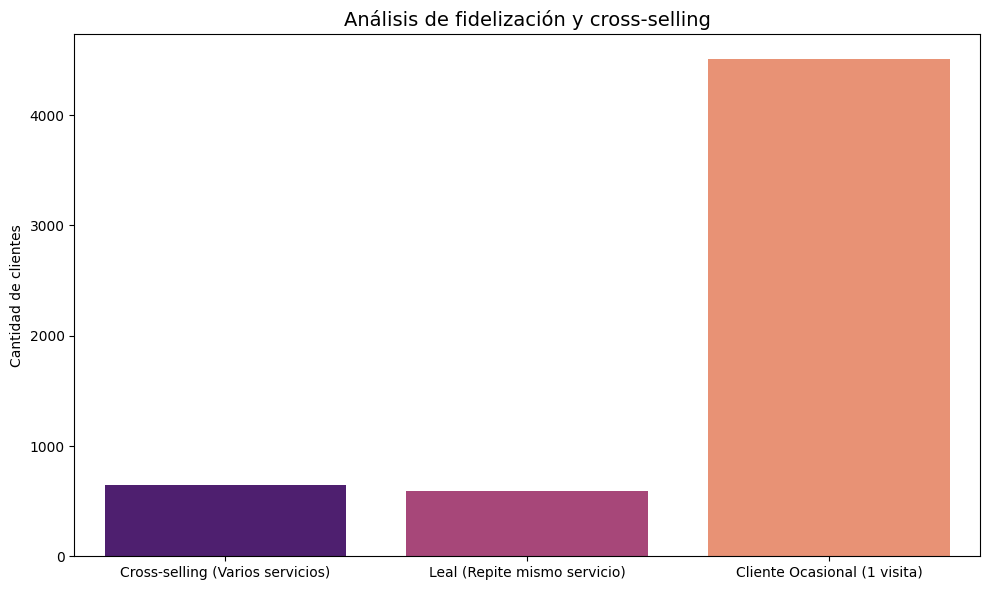

In [23]:
# Perfil de cliente: nº de servicios distintos y nº de visitas totales
perfil_cliente = (df_ventas.groupby('cliente_id')
                           .agg(servicios_distintos=('producto', 'nunique'),
                                visitas_totales=('neto', 'count')))

# Lógica de comportamiento (3 buckets exclusivos)
def definir_perfil(row):
    if row['visitas_totales'] > 1:
        if row['servicios_distintos'] > 1:
            return 'Cross-selling (Varios servicios)'
        return 'Leal (Repite mismo servicio)'
    return 'Cliente Ocasional (1 visita)'

perfil_cliente['categoria'] = perfil_cliente.apply(definir_perfil, axis=1)

# Visualización del embudo de retención
plt.figure(figsize=(10, 6))
sns.countplot(data=perfil_cliente, x='categoria',
              palette='magma', hue='categoria', legend=False)
plt.title('Análisis de fidelización y cross-selling', fontsize=14)
plt.ylabel('Cantidad de clientes')
plt.xlabel('')
plt.tight_layout()
plt.savefig('../img/04_analisis_retencion.png', dpi=200)
plt.show()

=== Reparto sobre el TOTAL de clientes únicos ===
  Cliente Ocasional (1 visita)             4,508  (78.5%)
  Cross-selling (Varios servicios)           643  (11.2%)
  Leal (Repite mismo servicio)               595  (10.4%)
  TOTAL                                    5,746

=== Entre los 1,238 clientes recurrentes (>1 visita) ===
  Leales (mismo servicio):         595  (48.1%)
  Cross-selling (varios):          643  (51.9%)
  Mediana de visitas:             2
  Mediana de servicios distintos: 2
  Ratio cross-selling / leal:     1.08


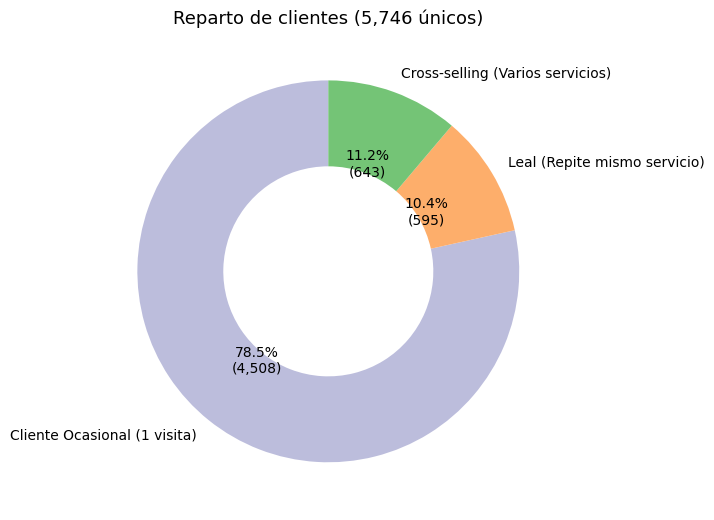

In [24]:
# Cuantificación detallada para el veredicto
total_clientes = len(perfil_cliente)
counts = perfil_cliente['categoria'].value_counts()
pcts   = (counts / total_clientes * 100).round(1)

print("=== Reparto sobre el TOTAL de clientes únicos ===")
for cat in counts.index:
    print(f"  {cat:40s} {counts[cat]:>5,}  ({pcts[cat]:.1f}%)")
print(f"  {'TOTAL':40s} {total_clientes:>5,}")
print()

# Sobre clientes RECURRENTES
recurrentes = perfil_cliente[perfil_cliente['visitas_totales'] > 1]
n_leal  = (recurrentes['categoria'] == 'Leal (Repite mismo servicio)').sum()
n_cross = (recurrentes['categoria'] == 'Cross-selling (Varios servicios)').sum()
n_rec   = len(recurrentes)

print(f"=== Entre los {n_rec:,} clientes recurrentes (>1 visita) ===")
print(f"  Leales (mismo servicio):        {n_leal:>4,}  ({n_leal/n_rec*100:.1f}%)")
print(f"  Cross-selling (varios):         {n_cross:>4,}  ({n_cross/n_rec*100:.1f}%)")
print(f"  Mediana de visitas:             {recurrentes['visitas_totales'].median():.0f}")
print(f"  Mediana de servicios distintos: {recurrentes['servicios_distintos'].median():.0f}")
print(f"  Ratio cross-selling / leal:     {n_cross/n_leal:.2f}")

# Donut con reparto y porcentajes
plt.figure(figsize=(7, 7))
colores = ['#bcbddc', '#fdae6b', '#74c476']
orden = ['Cliente Ocasional (1 visita)',
         'Leal (Repite mismo servicio)',
         'Cross-selling (Varios servicios)']
counts_ord = counts.reindex(orden)
plt.pie(counts_ord, labels=counts_ord.index,
        autopct=lambda p: f'{p:.1f}%\n({int(round(p*total_clientes/100)):,})',
        colors=colores, startangle=90, wedgeprops=dict(width=0.45))
plt.title(f'Reparto de clientes ({total_clientes:,} únicos)', fontsize=13)
plt.tight_layout()
plt.savefig('../img/04_reparto_clientes.png', dpi=200)
plt.show()

### Veredicto H4 — **REFUTADA** (el cross-selling gana ligeramente, pero el hallazgo dominante es otro)

**Resumen cuantitativo (5.746 clientes únicos):**

| Categoría | Clientes | % del total |
|---|---:|---:|
| Ocasional (1 visita) | **4.508** | **78,5 %** |
| Cross-selling (varios servicios) | 643 | 11,2 % |
| Leal (repite mismo servicio) | 595 | 10,4 % |

**Entre los 1.238 clientes recurrentes (>1 visita):**

| | Clientes | % de recurrentes |
|---|---:|---:|
| **Cross-selling** | **643** | **51,9 %** |
| Leal (repite mismo) | 595 | 48,1 % |
| Mediana de visitas | 2 | — |
| Mediana de servicios distintos | 2 | — |

**Interpretación:**

1. **La hipótesis se refuta:** entre los clientes recurrentes el cross-selling (51,9 %) supera ligeramente a la repetición del mismo servicio (48,1 %). El cliente del Oasis Spa que repite tiende **levemente** a **explorar** distintos productos antes que a quedarse con uno.
2. **El hallazgo realmente importante NO es el del enunciado**: el **78,5 % de la base es Cliente Ocasional**. La conversación correcta para el negocio no es "leales vs. cross-selling" (donde la diferencia es marginal, 643 vs. 595), sino **cómo convertir al ocasional en recurrente**. Solo 1 de cada 5 clientes vuelve.
3. **El cross-selling existe pero es modesto en intensidad:** la mediana del cliente recurrente es **2 visitas** y **2 servicios distintos**. Cuando un cliente repite, suele probar un servicio nuevo; pero el número de visitas es muy bajo en cualquier caso.

**Implicación de negocio:**
- **Prioridad #1 — Conversión ocasional → recurrente:** la mayor palanca de crecimiento es elevar la tasa de retención. Líneas: email post-visita, descuento de segunda visita, programa de fidelización ligero.
- **Prioridad #2 — Aprovechar la curiosidad natural del recurrente:** dado que el cross-selling supera ligeramente a la repetición, las recomendaciones personalizadas ("la próxima vez prueba…") y los packs combinados son una venta natural; no se está empujando a los leales fuera de su zona de confort.
- **Reformulación de KPI:** monitorizar "tasa de retención" (% que vuelve en N meses) por encima de "leal vs cross-selling", porque ahí está el verdadero margen de mejora.